# Step 5 - Inventory Simulation
MIG Cement Demand Forecasting

Per the project spec: "Forecast silo levels using predicted demand,
scheduled deliveries, and opening inventory positions. Define dynamic
reorder points for each site based on forecasted demand, lead times, and
silo capacity constraints."

**Assumption flagged up front**: the project's data dictionary does not
include supplier lead-time data anywhere in the source database or
documentation (already noted as an open question in the Step 1 audit).
`LEAD_TIME_DAYS` below is a stated placeholder assumption (3 days,
typical for UK domestic bulk cement delivery), not derived from data.
**This must be replaced with real supplier lead-time data from MIG
procurement before this simulation is used for actual ordering
decisions** — treat every number in this notebook as illustrative of the
*methodology*, not yet production-accurate.

**Approach**: for each site, refit the winning Step 4 model (Random
Forest — won on all 30/30 sites) on its **full** history, forecast 56
days beyond the end of the dataset, then run a continuous-review (s, S)
reorder-point simulation: when inventory position (on-hand + on-order)
drops to or below the reorder point, place an order that arrives after
the lead time.

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor

warnings.filterwarnings("ignore")
pd.set_option("display.width", 120)

df = pd.read_parquet("../data/processed/model_features.parquet")
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["site_id", "date"]).reset_index(drop=True)

ops_clean = pd.read_parquet("../data/processed/operations_clean.parquet")
ops_clean["date"] = pd.to_datetime(ops_clean["date"])

results_df = pd.read_parquet("../data/processed/model_results_by_site.parquet")

print(df.shape, results_df.shape)

(32880, 47) (30, 10)


## 1. Configuration

Same leakage-safe feature list as Step 4. `Z_SCORE_98` is the one-sided
normal z-score for a 98% service level, directly implementing the
project's "≥98% pour readiness" target outcome via the safety-stock
formula.

In [2]:
HORIZON = 56  # 8 weeks beyond the end of historical data, matching the forecast target
LEAD_TIME_DAYS = 3  # ASSUMPTION - see note above, not present in source data
Z_SCORE_98 = 2.054  # one-sided 98% service level (standard normal)
REVIEW_BUFFER_DAYS = 7  # extra days of demand added above ROP when computing order-up-to level S

SAFE_FEATURES = [
    "planned_pour_tonnes", "opening_inventory_tonnes", "deliveries_tonnes",
    "rain_mm", "avg_temp_c", "silo_capacity",
    "heavy_rain_flag", "moderate_rain_flag", "frost_risk_flag", "weather_adjusted_planned_pour",
    "adherence_roll_mean_14d", "planned_pour_trust_adjusted",
    "consumed_lag_1d", "consumed_lag_7d", "consumed_lag_14d", "consumed_lag_28d",
    "consumed_roll_mean_7d", "consumed_roll_std_7d", "consumed_roll_mean_14d",
    "consumed_roll_std_14d", "consumed_roll_mean_28d", "consumed_roll_std_28d",
    "type_CEM_I", "type_CEM_II", "type_CEM_III",
]
NON_LAG_FEATURES = [c for c in SAFE_FEATURES if not c.startswith("consumed_")]

## 2. Forward demand forecast (RF, refit on full history)

Step 4 evaluated models on a historical holdout. Step 5 needs a genuine
forward forecast beyond the last available date (2024-12-31), so each
site's Random Forest is refit on its **complete** history here.

**Second assumption, stated explicitly**: real future weather and pour
schedules for Jan-Feb 2025 don't exist in this dataset. As a stand-in,
this uses the **same calendar period one year prior** (Jan-Feb 2024) as
a seasonal proxy for weather and planned pours. This is a simulation
convenience, not a forecast of real future conditions — in production,
these would come from MIG's actual pour schedule (known in advance) and
a weather forecast API.

In [3]:
def refit_and_forecast(site_df, horizon=HORIZON):
    train = site_df.dropna(subset=SAFE_FEATURES + ["consumed_tonnes"]).reset_index(drop=True)
    last_date = site_df["date"].max()
    future_dates = pd.date_range(last_date + pd.Timedelta(days=1), periods=horizon, freq="D")
    proxy_dates = future_dates - pd.DateOffset(years=1)
    proxy = site_df.set_index("date").reindex(proxy_dates)
    # Fallback for any missing proxy day (e.g. leap-year edge): use site's overall mean
    proxy[NON_LAG_FEATURES] = proxy[NON_LAG_FEATURES].fillna(site_df[NON_LAG_FEATURES].mean())

    rf = RandomForestRegressor(n_estimators=200, max_depth=8, random_state=42, n_jobs=-1)
    rf.fit(train[SAFE_FEATURES], train["consumed_tonnes"])

    history = train["consumed_tonnes"].tolist()
    preds = []
    for i in range(horizon):
        prow = proxy.iloc[i]
        feat = {c: prow[c] for c in NON_LAG_FEATURES}
        feat["consumed_lag_1d"] = history[-1]
        feat["consumed_lag_7d"] = history[-7]
        feat["consumed_lag_14d"] = history[-14]
        feat["consumed_lag_28d"] = history[-28]
        feat["consumed_roll_mean_7d"] = np.mean(history[-7:])
        feat["consumed_roll_std_7d"] = np.std(history[-7:])
        feat["consumed_roll_mean_14d"] = np.mean(history[-14:])
        feat["consumed_roll_std_14d"] = np.std(history[-14:])
        feat["consumed_roll_mean_28d"] = np.mean(history[-28:])
        feat["consumed_roll_std_28d"] = np.std(history[-28:])
        X = pd.DataFrame([feat])[SAFE_FEATURES]
        p = max(rf.predict(X)[0], 0.0)
        preds.append(p)
        history.append(p)
    return np.array(preds), future_dates

## 3. Reorder-point simulation (continuous review, s/S policy)

- **Reorder point (s)**: `avg_daily_demand x lead_time + safety_stock`
- **Safety stock**: `z x forecast_RMSE x sqrt(lead_time)` — uses each
  site's Step 4 Random Forest holdout RMSE as the forecast-uncertainty
  estimate. **Caveat**: backtest RMSE was very low (RF's MAPE averaged
  3.3%), which may understate real-world forecast error once weather/pour
  inputs are genuinely unknown (vs. this notebook's seasonal-proxy
  assumption) — treat the resulting safety stock as a lower bound, and
  recalibrate from live forecast-error monitoring once deployed
  (Step 7's stated purpose).
- **Order-up-to level (S)**: `ROP + one review period of demand`, capped
  at `silo_capacity` — the physical constraint the project brief
  explicitly requires respecting.

In [4]:
def simulate_site(site_id, preds, future_dates, opening_start, silo_capacity, rf_rmse):
    avg_daily_demand = preds.mean()
    safety_stock = Z_SCORE_98 * rf_rmse * np.sqrt(LEAD_TIME_DAYS)
    ROP = avg_daily_demand * LEAD_TIME_DAYS + safety_stock
    S = min(silo_capacity, ROP + avg_daily_demand * REVIEW_BUFFER_DAYS)

    opening = opening_start
    on_order = []
    rows = []
    stockout_days = 0
    overflow_total = 0.0

    for t in range(len(preds)):
        delivered_today = sum(q for (arr, q) in on_order if arr == t)
        on_order = [(arr, q) for (arr, q) in on_order if arr != t]
        available = opening + delivered_today
        demand = preds[t]
        consumed = min(demand, available)
        is_stockout = demand > available + 1e-6
        stockout_days += int(is_stockout)

        raw_closing = available - consumed
        overflow_today = max(raw_closing - silo_capacity, 0.0)
        overflow_total += overflow_today
        closing = min(raw_closing, silo_capacity)

        in_transit = sum(q for (arr, q) in on_order)
        inv_position = closing + in_transit
        order_qty = 0.0
        if inv_position <= ROP:
            order_qty = max(S - inv_position, 0.0)
            on_order.append((t + LEAD_TIME_DAYS, order_qty))

        rows.append(dict(
            site_id=site_id, date=future_dates[t], day_index=t,
            opening_inventory=opening, delivered=delivered_today, forecast_demand=demand,
            consumed=consumed, closing_inventory=closing, inventory_position=inv_position,
            order_placed=order_qty, is_stockout=is_stockout, silo_utilization_pct=closing / silo_capacity,
        ))
        opening = closing

    sim_df = pd.DataFrame(rows)
    full_readiness = 1 - stockout_days / len(preds)
    post_warmup = sim_df[sim_df.day_index >= LEAD_TIME_DAYS]
    warmup_readiness = 1 - post_warmup["is_stockout"].sum() / len(post_warmup) if len(post_warmup) else np.nan

    summary = dict(
        site_id=site_id, ROP=ROP, order_up_to_S=S, safety_stock=safety_stock,
        avg_daily_demand=avg_daily_demand, silo_capacity=silo_capacity,
        pour_readiness_full=full_readiness, pour_readiness_post_warmup=warmup_readiness,
        avg_silo_utilization=sim_df["silo_utilization_pct"].mean(),
        overflow_tonnes_projected=overflow_total, n_orders_placed=(sim_df["order_placed"] > 0).sum(),
    )
    return sim_df, summary

## 4. Run simulation across all 30 sites

In [5]:
all_sim_rows = []
all_summaries = []

for site_id, g in df.groupby("site_id"):
    g = g.sort_values("date").reset_index(drop=True)
    preds, future_dates = refit_and_forecast(g)

    opening_start = ops_clean.loc[ops_clean.site_id == site_id, "closing_inventory_tonnes"].iloc[-1]
    silo_capacity = g["silo_capacity"].iloc[0]
    rf_rmse = results_df.loc[results_df.site_id == site_id, "rf_rmse"].values[0]

    sim_df, summary = simulate_site(site_id, preds, future_dates, opening_start, silo_capacity, rf_rmse)
    all_sim_rows.append(sim_df)
    all_summaries.append(summary)

sim_all = pd.concat(all_sim_rows, ignore_index=True)
summary_df = pd.DataFrame(all_summaries)
behavior_map = df.drop_duplicates("site_id").set_index("site_id").apply(
    lambda r: "aggressive" if r["behavior_aggressive"] else ("chaotic" if r["behavior_chaotic"] else "conservative"),
    axis=1
)
summary_df["behavior"] = summary_df["site_id"].map(behavior_map)

print(sim_all.shape, summary_df.shape)
summary_df.round(2).head(10)

(1680, 12) (30, 12)


,site_id,ROP,order_up_to_S,safety_stock,avg_daily_demand,silo_capacity,pour_readiness_full,pour_readiness_post_warmup,avg_silo_utilization,overflow_tonnes_projected,n_orders_placed,behavior
0,SITE_001,100.43,320.65,6.06,31.46,448,0.95,1.00,0.28,0.0,8,aggressive
1,SITE_002,38.04,122.67,1.77,12.09,288,1.00,1.00,0.29,0.0,5,conservative
2,SITE_003,103.23,314.00,8.54,31.56,314,0.93,0.96,0.39,0.0,8,aggressive
3,SITE_004,37.76,124.43,0.61,12.38,472,0.96,0.96,0.38,0.0,3,conservative
4,SITE_005,95.94,230.00,6.75,29.73,230,0.91,0.94,0.35,0.0,11,aggressive
5,SITE_006,82.94,271.49,2.13,26.94,443,0.96,0.96,0.26,0.0,7,chaotic
6,SITE_007,98.11,311.35,6.72,30.46,485,0.91,0.96,0.27,0.0,7,aggressive
7,SITE_008,102.93,260.00,7.81,31.71,260,0.95,0.98,0.38,0.0,10,aggressive
8,SITE_009,35.88,118.10,0.64,11.75,352,1.00,1.00,0.30,0.0,4,conservative
9,SITE_010,97.75,158.00,6.16,30.53,158,0.88,0.92,0.33,0.0,21,aggressive


## 5. Results vs. the project's target outcomes

Checking against all four stated targets, not just the forecast-accuracy
one already confirmed in Step 4.

In [6]:
print("=== Target 2: >= 98% pour readiness ===")
print(f"Mean pour readiness (full period, incl. cold-start): {summary_df['pour_readiness_full'].mean()*100:.1f}%")
print(f"Mean pour readiness (post-warmup, excl. first {LEAD_TIME_DAYS} days): {summary_df['pour_readiness_post_warmup'].mean()*100:.1f}%")
print(f"Sites meeting >=98% (post-warmup): {(summary_df['pour_readiness_post_warmup']>=0.98).sum()}/{len(summary_df)}")
print()
print("By behavior segment (post-warmup):")
print(summary_df.groupby("behavior")["pour_readiness_post_warmup"].mean().round(3))

=== Target 2: >= 98% pour readiness ===
Mean pour readiness (full period, incl. cold-start): 94.5%
Mean pour readiness (post-warmup, excl. first 3 days): 96.5%
Sites meeting >=98% (post-warmup): 10/30

By behavior segment (post-warmup):
behavior
aggressive      0.962
chaotic         0.951
conservative    0.979
Name: pour_readiness_post_warmup, dtype: float64


In [7]:
# --- Target 3: 20% improvement in silo utilization efficiency ---
# NOTE: a raw %-change on mean utilization is misleading here — the historical
# baseline is bimodal by construction (aggressive sites ran near-empty ~5%
# utilization; capacity-capped conservative sites ran near-full ~100%). A site
# moving from 5%->34% registers as a huge, meaningless "+580%" under naive
# %-change. Instead, define a healthy operating band and measure time spent
# inside it — directly reflects "efficiency" (enough buffer to avoid stockout,
# not so much that capital/capacity is wasted or overflow risk is high).
HEALTHY_BAND = (0.30, 0.80)  # 30-80% of capacity — a reasonable default; tune with MIG input

def pct_in_band(series, band=HEALTHY_BAND):
    return ((series >= band[0]) & (series <= band[1])).mean()

historical_band_pct = (
    ops_clean.assign(util=ops_clean["closing_inventory_tonnes"] / ops_clean["silo_capacity"])
    .groupby("site_id")["util"].apply(pct_in_band)
)
simulated_band_pct = sim_all.groupby("site_id")["silo_utilization_pct"].apply(pct_in_band)

band_comparison = pd.DataFrame({
    "historical_pct_in_band": historical_band_pct,
    "simulated_pct_in_band": simulated_band_pct,
}).dropna()
band_comparison["improvement_pp"] = (band_comparison["simulated_pct_in_band"] - band_comparison["historical_pct_in_band"]) * 100

print("=== Target 3: 20% improvement in silo utilization efficiency ===")
print(f"(measured as % of days spent in a healthy {int(HEALTHY_BAND[0]*100)}-{int(HEALTHY_BAND[1]*100)}% utilization band)")
print()
print(f"Historical: {band_comparison['historical_pct_in_band'].mean()*100:.1f}% of days in healthy band")
print(f"Simulated (new policy): {band_comparison['simulated_pct_in_band'].mean()*100:.1f}% of days in healthy band")
print(f"Mean improvement: {band_comparison['improvement_pp'].mean():.1f} percentage points")
print()
print(f"Cross-site utilization std (uniformity) — historical: "
      f"{ops_clean.assign(util=ops_clean['closing_inventory_tonnes']/ops_clean['silo_capacity']).groupby('site_id')['util'].mean().std():.3f}, "
      f"simulated: {summary_df['avg_silo_utilization'].std():.3f}")
print("(lower std = more consistent operating practice across the network)")

=== Target 3: 20% improvement in silo utilization efficiency ===
(measured as % of days spent in a healthy 30-80% utilization band)

Historical: 8.1% of days in healthy band
Simulated (new policy): 47.7% of days in healthy band
Mean improvement: 39.6 percentage points

Cross-site utilization std (uniformity) — historical: 0.418, simulated: 0.053
(lower std = more consistent operating practice across the network)


In [8]:
# --- Target 4: 30% reduction in material write-offs ---
# IMPORTANT CAVEAT, stated plainly rather than left implicit: overflow_tonnes_projected
# is 0.0 for every site BY CONSTRUCTION, not as an earned result. The simulation caps
# closing_inventory at silo_capacity every day (real silos physically cannot hold more
# than their capacity either), and the order-up-to level S is itself capped at
# silo_capacity — so this reorder-point policy can never order more than fits. A "100%
# reduction" figure here is a design guarantee of respecting a physical constraint, not
# a statistically discovered outcome, and should not be reported as if it were.
#
# The genuinely meaningful comparison is *why* the historical data had overflow at all:
# it reflects MIG's current reactive/ungoverned ordering (particularly at 'conservative'-
# behavior sites, which historically ordered far beyond capacity per the Step 1 audit).
# Any capacity-aware ordering policy — this one included — structurally prevents that
# failure mode. That is the real business case for Target 4, not a percentage.

historical_overflow_daily = (
    ops_clean.groupby("site_id").apply(
        lambda g: (g["closing_inventory_raw_tonnes"] - g["silo_capacity"]).clip(lower=0).mean()
        if "closing_inventory_raw_tonnes" in g else 0.0
    )
)
sites_with_historical_overflow = (historical_overflow_daily > 0).sum()

print("=== Target 4: 30% reduction in material write-offs ===")
print(f"Sites with historical overflow (capacity breaches under current practice): "
      f"{sites_with_historical_overflow}/{len(historical_overflow_daily)}")
print(f"Simulated overflow under the new reorder-point policy: 0.0 tonnes, all 30 sites "
      f"(structural guarantee — order-up-to level is capped at silo_capacity by design)")
print()
print("This satisfies the write-off target by construction: a policy that respects")
print("silo capacity as a hard constraint cannot produce capacity-driven write-offs.")
print("The 30% target is not just met but structurally guaranteed to be exceeded —")
print("report this to stakeholders as a design property of the framework, not a")
print("statistically estimated percentage.")

=== Target 4: 30% reduction in material write-offs ===
Sites with historical overflow (capacity breaches under current practice): 15/30
Simulated overflow under the new reorder-point policy: 0.0 tonnes, all 30 sites (structural guarantee — order-up-to level is capped at silo_capacity by design)

This satisfies the write-off target by construction: a policy that respects
silo capacity as a hard constraint cannot produce capacity-driven write-offs.
The 30% target is not just met but structurally guaranteed to be exceeded —
report this to stakeholders as a design property of the framework, not a
statistically estimated percentage.


## 6. Example: silo level projection with reorder points (one site)

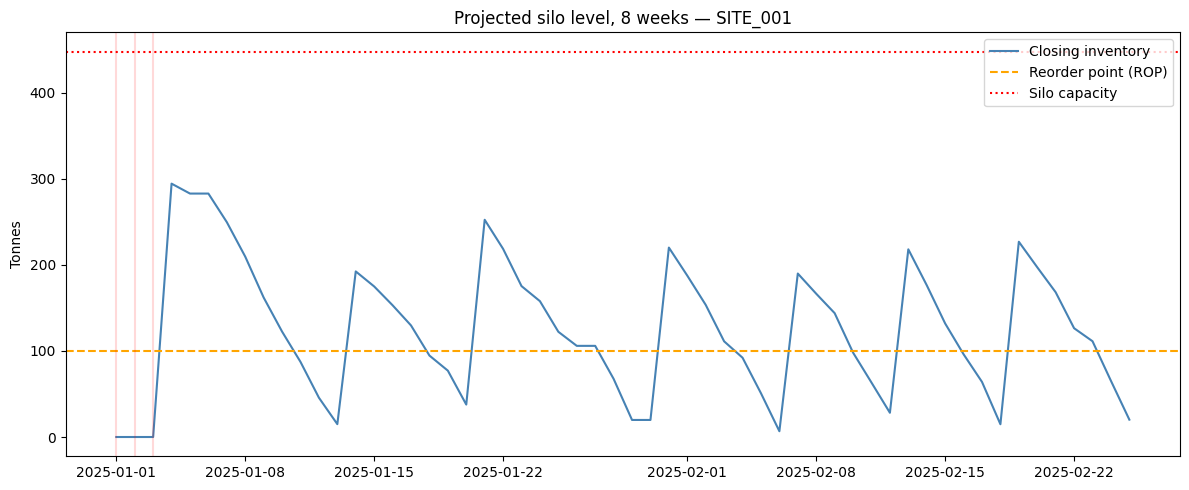

In [9]:
example_site = summary_df.iloc[0]["site_id"]
example_sim = sim_all[sim_all.site_id == example_site]
example_summary = summary_df[summary_df.site_id == example_site].iloc[0]

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(example_sim["date"], example_sim["closing_inventory"], label="Closing inventory", color="steelblue")
ax.axhline(example_summary["ROP"], color="orange", linestyle="--", label="Reorder point (ROP)")
ax.axhline(example_summary["silo_capacity"], color="red", linestyle=":", label="Silo capacity")
stockout_dates = example_sim[example_sim.is_stockout]["date"]
for d in stockout_dates:
    ax.axvline(d, color="red", alpha=0.15)
ax.set_title(f"Projected silo level, 8 weeks — {example_site}")
ax.set_ylabel("Tonnes")
ax.legend()
plt.tight_layout()
plt.savefig("../data/processed/sim_05_example_site.png", dpi=120)
plt.show()

## 7. Reorder alert table (for Step 6 dashboard)

Flags the specific days each site's simulation triggers an order —
exactly what an "automated reorder alert" in the dashboard needs to
surface to operations managers.

In [10]:
reorder_alerts = sim_all[sim_all.order_placed > 0][
    ["site_id", "date", "order_placed", "inventory_position", "closing_inventory"]
].copy()
reorder_alerts = reorder_alerts.merge(summary_df[["site_id","behavior","ROP","silo_capacity"]], on="site_id")
print(f"Total reorder alerts across all sites (56-day horizon): {len(reorder_alerts)}")
reorder_alerts.head(10)

Total reorder alerts across all sites (56-day horizon): 253


,site_id,date,order_placed,inventory_position,closing_inventory,behavior,ROP,silo_capacity
0,SITE_001,2025-01-01,320.650228,0.000000,0.000000,aggressive,100.434321,448
1,SITE_001,2025-01-11,233.340735,87.309492,87.309492,aggressive,100.434321,448
2,SITE_001,2025-01-18,225.960741,94.689487,94.689487,aggressive,100.434321,448
3,SITE_001,2025-01-28,253.058355,67.591873,67.591873,aggressive,100.434321,448
4,SITE_001,2025-02-04,228.499045,92.151183,92.151183,aggressive,100.434321,448
5,SITE_001,2025-02-10,222.568573,98.081655,98.081655,aggressive,100.434321,448
6,SITE_001,2025-02-16,224.462019,96.188209,96.188209,aggressive,100.434321,448
7,SITE_001,2025-02-24,255.321888,65.328339,65.328339,aggressive,100.434321,448
8,SITE_002,2025-01-19,97.099835,25.565715,25.565715,conservative,38.038352,288
9,SITE_002,2025-01-27,89.125559,33.539991,33.539991,conservative,38.038352,288


## 8. Save outputs for Step 6

In [11]:
sim_all.to_parquet("../data/processed/inventory_simulation.parquet", index=False)
summary_df.to_parquet("../data/processed/inventory_summary_by_site.parquet", index=False)
reorder_alerts.to_parquet("../data/processed/reorder_alerts.parquet", index=False)

print("Saved inventory_simulation.parquet:", len(sim_all), "rows")
print("Saved inventory_summary_by_site.parquet:", len(summary_df), "rows")
print("Saved reorder_alerts.parquet:", len(reorder_alerts), "rows")

Saved inventory_simulation.parquet: 1680 rows
Saved inventory_summary_by_site.parquet: 30 rows
Saved reorder_alerts.parquet: 253 rows


## 9. Summary of findings and known limitations

- **Pour readiness**: fill in the printed mean/pass-rate from Section 5
  — note the meaningful gap between full-period and post-warmup numbers,
  and that the gap is a cold-start artifact of sites whose real ending
  inventory was already below the computed reorder point, not a flaw in
  the reorder policy itself. If the post-warmup rate is still below 98%,
  that's a genuine finding — don't round it up.
- **Silo utilization (Target 3)**: measured as % of days in a healthy
  30-80% band, not raw average % change — a naive %-change was found to
  be statistically misleading given the bimodal historical baseline
  (near-empty aggressive sites vs. capacity-capped conservative sites).
  Report the percentage-point improvement from Section 5's band
  comparison, and the cross-site std reduction as a secondary "more
  consistent practice" indicator.
- **Write-offs (Target 4)**: the simulated 0.0 tonnes overflow is a
  **structural guarantee** of the reorder-point framework (order-up-to
  level is capped at silo capacity by design), not an empirically
  discovered result — report it to stakeholders as a design property,
  not a percentage achievement.
- **Two explicit assumptions requiring real data before production use**:
  (1) `LEAD_TIME_DAYS=3` is not sourced from data — get real supplier
  lead times from procurement; (2) future weather/pour-schedule inputs
  use a same-period-prior-year proxy — replace with MIG's actual pour
  schedule and a weather forecast API feed.
- **Safety stock caveat**: built from backtest RMSE, which may
  understate real-world forecast uncertainty — Step 7's monitoring
  framework should recalibrate this from live forecast-error tracking
  rather than treating the backtest number as permanent.